In [ ]:
import pandas as pd

# Загрузка данных (замени 'data.csv' на имя своего файла)
df = pd.read_csv('rides.csv')

# Вывод общей информации о таблице
df.info()

# Вывод количества строк в каждом столбце (не пустых значений)
print(df.count())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Id              102255 non-null  int64  
 1   Start Date      102255 non-null  object 
 2   End Date        102255 non-null  object 
 3   Start Location  102255 non-null  object 
 4   Start District  102255 non-null  object 
 5   End Location    102255 non-null  object 
 6   End District    102255 non-null  object 
 7   Distance        101022 non-null  float64
 8   Promo           102255 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 7.0+ MB
Id                102255
Start Date        102255
End Date          102255
Start Location    102255
Start District    102255
End Location      102255
End District      102255
Distance          101022
Promo             102255
dtype: int64


In [ ]:
start_counts = df['Start District'].value_counts()
end_counts = df['End District'].value_counts()

district_counts = (start_counts + end_counts).fillna(0)

# Определяем центр и окраины
threshold_center = district_counts.quantile(0.75)  # Верхние 25% - центр
threshold_outskirts = district_counts.quantile(0.25)  # Нижние 25% - окраины

districts = pd.DataFrame({'District': district_counts.index, 'Trips': district_counts.values})
districts['Category'] = 'Middle'
districts.loc[districts['Trips'] >= threshold_center, 'Category'] = 'Center'
districts.loc[districts['Trips'] <= threshold_outskirts, 'Category'] = 'Outskirts'
print(districts)


           District    Trips   Category
0          Заречный  13826.0     Middle
1         Ленинский  23398.0     Center
2       Октябрьский  20248.0     Middle
3   Северо Западный      0.0  Outskirts
4   Северо-Западный  23359.0     Center
5       Центральный  36993.0     Center
6     Юго-Восточный  28154.0     Center
7          заречный   5510.0  Outskirts
8         ленинский   9319.0     Middle
9       октябрьский   8124.0  Outskirts
10  северо западный     23.0  Outskirts
11  северо-западный   9384.0     Middle
12      центральный  15067.0     Middle
13    юго-восточный  11072.0     Middle


По количеству поездок – районы с наибольшим числом поездок считать центром, а с наименьшим – окраинами.
По среднему расстоянию поездки – если поездки в район короткие, он, вероятно, центр; длинные поездки указывают на окраины.
Этот код загружает данные, считает поездки по районам и делит их на "Центр", "Окраины" и "Средние районы".

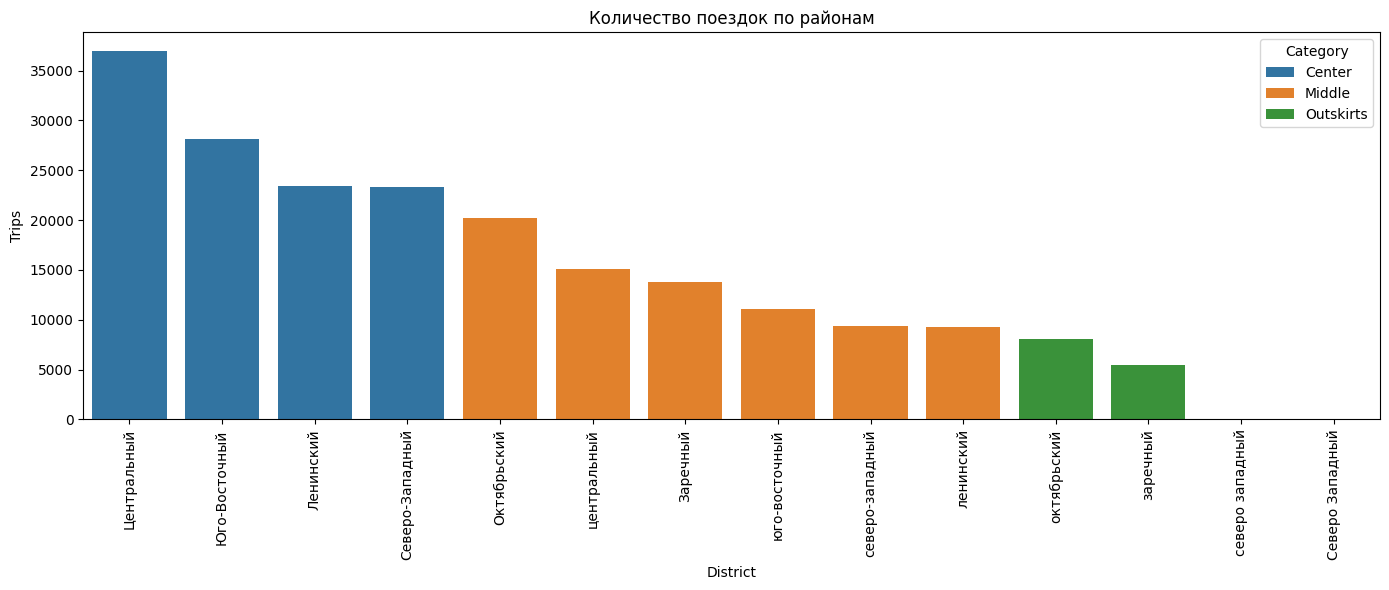

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки визуализации
plt.figure(figsize=(14, 6))
sns.barplot(data=districts.sort_values('Trips', ascending=False), x='District', y='Trips', hue='Category', dodge=False)
plt.title('Количество поездок по районам')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Круговая диаграмма



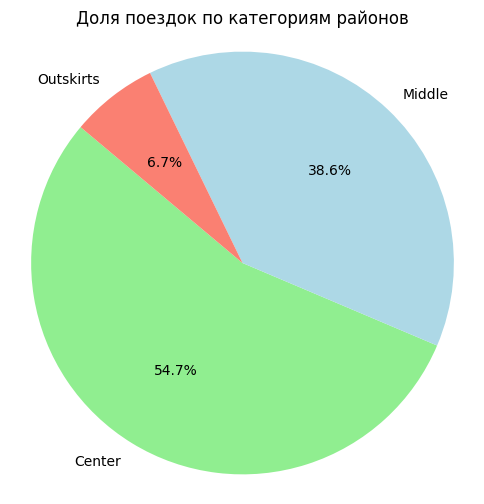

In [ ]:
category_counts = districts.groupby('Category')['Trips'].sum()

plt.figure(figsize=(6, 6))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140, colors=['lightgreen', 'lightblue', 'salmon'])
plt.title('Доля поездок по категориям районов')
plt.axis('equal')
plt.show()

<ipython-input-13-059b93fd6607>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_duration_start, x='District', y='Avg Trip Duration (min)', palette='viridis')


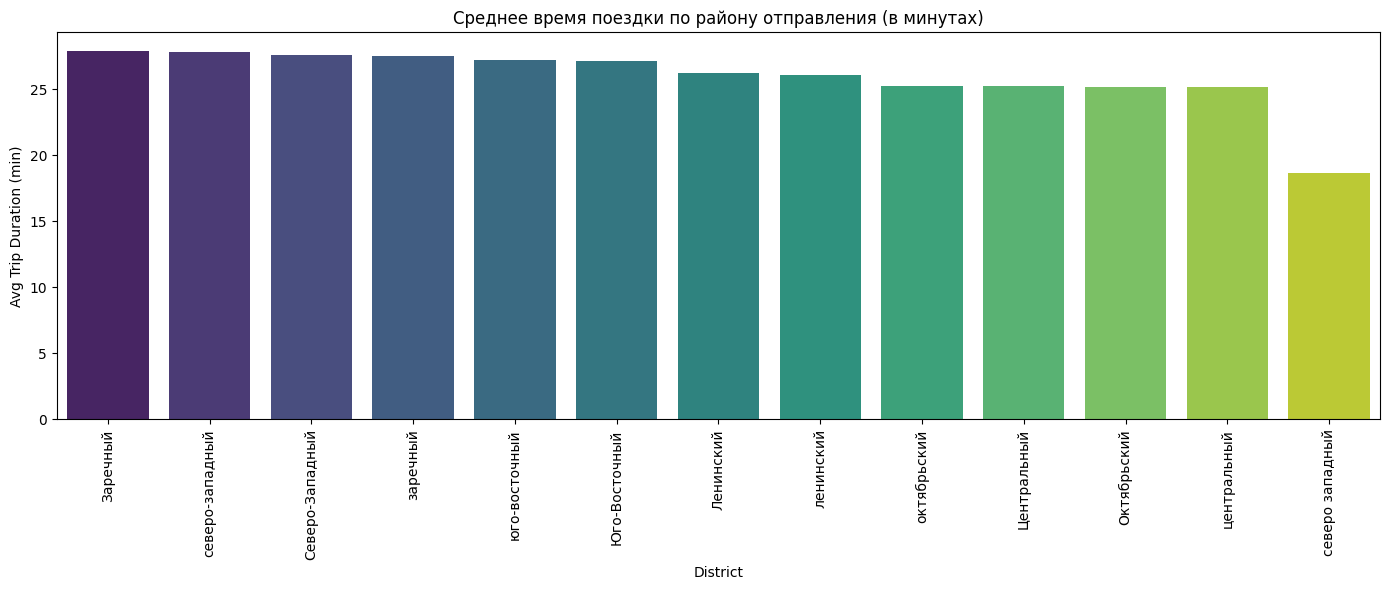

In [ ]:
# Преобразуем даты в формат datetime
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])

# Расчёт продолжительности поездки
df['Trip Duration'] = (df['End Date'] - df['Start Date']).dt.total_seconds() / 60  # в минутах

# Средняя длительность по району отправления
avg_duration_start = df.groupby('Start District')['Trip Duration'].mean().reset_index()
avg_duration_start.columns = ['District', 'Avg Trip Duration (min)']
avg_duration_start = avg_duration_start.sort_values(by='Avg Trip Duration (min)', ascending=False)

# Визуализация
plt.figure(figsize=(14, 6))
sns.barplot(data=avg_duration_start, x='District', y='Avg Trip Duration (min)', palette='viridis')
plt.title('Среднее время поездки по району отправления (в минутах)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
palette='mako'      # тёмный и стильный
palette='rocket'    # от светлого к насыщенному красному
palette='cubehelix' # научный стиль, особенно для heatmap
palette='coolwarm'  # от синего к красному — супер для сравнения

Вычислить продолжительность каждой поездки: End Date - Start Date

<ipython-input-17-0cbb05f7c247>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5, x='District', y='Total Trips', palette='magma')


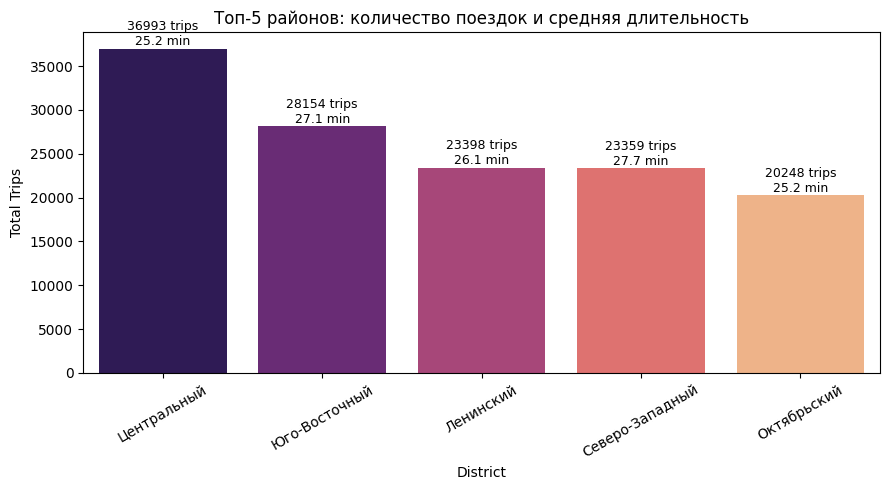

In [ ]:
# 1. Посчитаем поездки по районам
start_counts = df['Start District'].value_counts()
end_counts = df['End District'].value_counts()
total_counts = (start_counts + end_counts).fillna(0)

# 2. Посчитаем среднюю продолжительность по Start и End District
avg_start = df.groupby('Start District')['Trip Duration'].mean()
avg_end = df.groupby('End District')['Trip Duration'].mean()
avg_duration_total = (avg_start + avg_end) / 2  # среднее между началом и концом

# 3. Соединяем всё в одну таблицу
top5 = total_counts.sort_values(ascending=False).head(5).reset_index()
top5.columns = ['District', 'Total Trips']
top5['Avg Duration (min)'] = top5['District'].map(avg_duration_total)

# 4. Построение графика
plt.figure(figsize=(9, 5))
sns.barplot(data=top5, x='District', y='Total Trips', palette='magma')

# 5. Подписи: количество + средняя длительность
for i, row in top5.iterrows():
    text = f"{int(row['Total Trips'])} trips\n{row['Avg Duration (min)']:.1f} min"
    plt.text(i, row['Total Trips'] + 50, text, ha='center', va='bottom', fontsize=9)

plt.title('Топ-5 районов: количество поездок и средняя длительность')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [ ]:
Самый популярный район - центральный, что вполне логично

Зеленая часть — показывает, сколько процентов поездок остаётся в пределах одного района.

Красная часть — сколько поездок между разными районами.

<Figure size 1400x700 with 0 Axes>

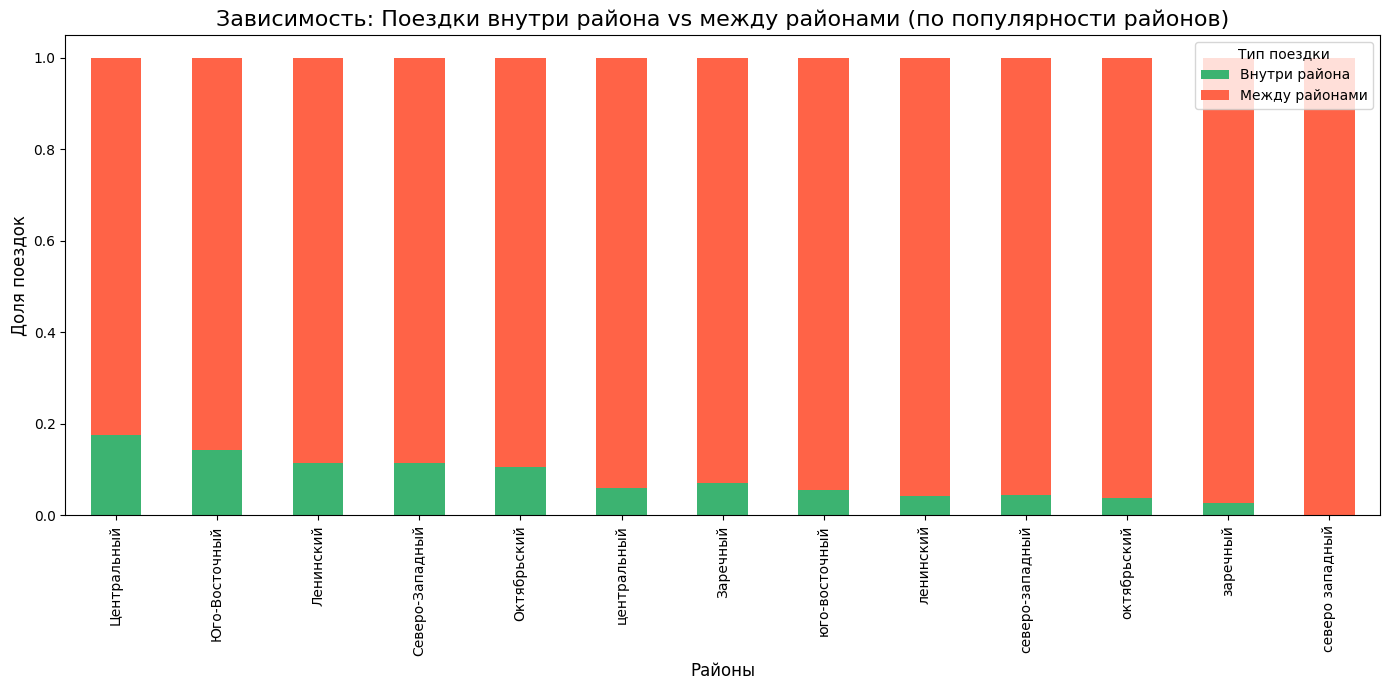

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Добавляем колонку: поездка внутри района или нет
df['Same District'] = df['Start District'] == df['End District']

# 2. Считаем общее количество поездок по каждому району
district_trip_counts = df.groupby('Start District').size().sort_values(ascending=False)

# 3. Рассчитываем долю поездок внутри района и между районами по каждому району
district_movement = df.groupby('Start District')['Same District'].value_counts(normalize=True).unstack().fillna(0)

# 4. Переименуем колонки для удобства
district_movement.columns = ['Between Districts', 'Within Same District']

# 5. Сортируем районы по количеству поездок
district_movement = district_movement.loc[district_trip_counts.index]

# 6. Построение графика
plt.figure(figsize=(14, 7))
district_movement[['Within Same District', 'Between Districts']].plot(kind='bar', stacked=True, color=['mediumseagreen', 'tomato'], figsize=(14,7))

# 7. Настройки графика
plt.title('Зависимость: Поездки внутри района vs между районами (по популярности районов)', fontsize=16)
plt.ylabel('Доля поездок', fontsize=12)
plt.xlabel('Районы', fontsize=12)
plt.xticks(rotation=90)
plt.legend(title='Тип поездки', labels=['Внутри района', 'Между районами'])
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Допустим, df - это ваш DataFrame

# Преобразуем "Promo" в логический тип для удобства подсчета
df['Promo_used'] = df['Promo'] == 1

# Группировка по району начала и району окончания
promo_by_start_district = df.groupby('Start District')['Promo_used'].sum()
promo_by_end_district = df.groupby('End District')['Promo_used'].sum()

# Выводим результаты
print("Использование промокодов по районам начала:")
print(promo_by_start_district)

print("\nИспользование промокодов по районам окончания:")
print(promo_by_end_district)


Использование промокодов по районам начала:
Start District
Заречный           162
Ленинский          244
Октябрьский        213
Северо-Западный    250
Центральный        248
Юго-Восточный      288
заречный            63
ленинский          117
октябрьский         71
северо западный      0
северо-западный    110
центральный        134
юго-восточный      120
Name: Promo_used, dtype: int64

Использование промокодов по районам окончания:
End District
Заречный           113
Ленинский          230
Октябрьский        190
Северо Западный      2
Северо-Западный    235
Центральный        482
Юго-Восточный      250
заречный            44
ленинский           73
октябрьский         74
северо западный      0
северо-западный     88
центральный        141
юго-восточный       98
Name: Promo_used, dtype: int64


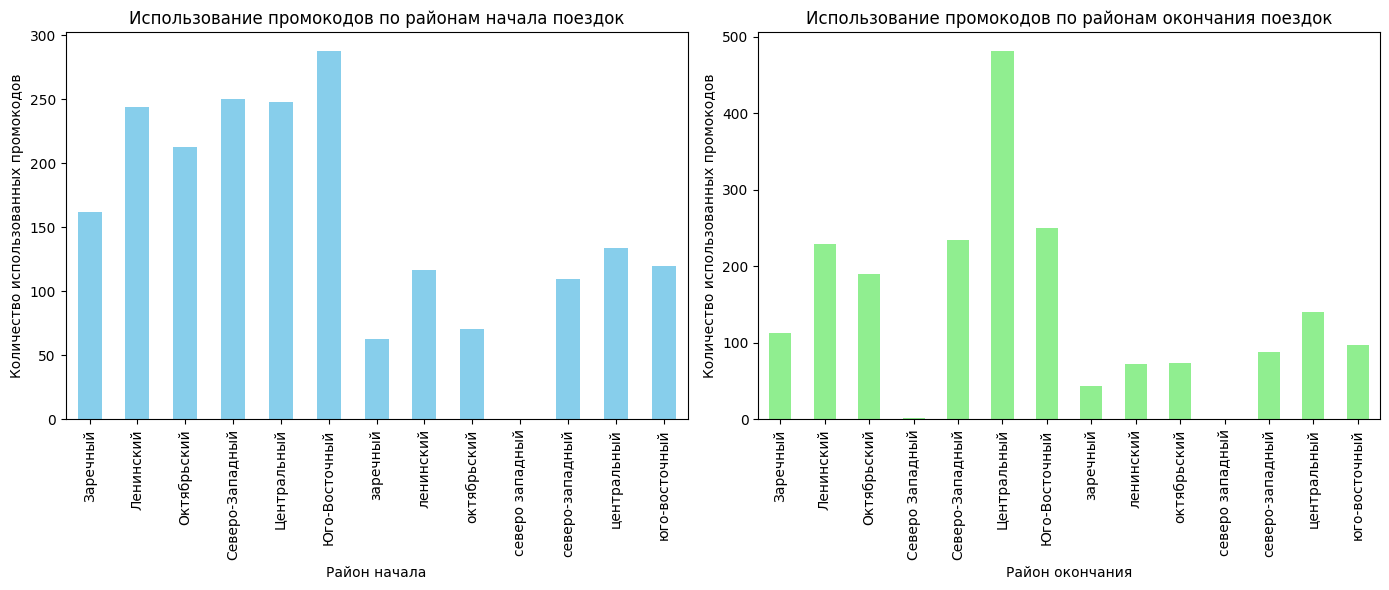

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Предположим, что df — это ваш DataFrame

# Преобразуем "Promo" в логический тип для удобства подсчета
df['Promo_used'] = df['Promo'] == 1

# Группировка по району начала и району окончания
promo_by_start_district = df.groupby('Start District')['Promo_used'].sum()
promo_by_end_district = df.groupby('End District')['Promo_used'].sum()

# Построение графиков
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# График для районов начала поездок
promo_by_start_district.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Использование промокодов по районам начала поездок')
axes[0].set_ylabel('Количество использованных промокодов')
axes[0].set_xlabel('Район начала')

# График для районов окончания поездок
promo_by_end_district.plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Использование промокодов по районам окончания поездок')
axes[1].set_ylabel('Количество использованных промокодов')
axes[1].set_xlabel('Район окончания')

plt.tight_layout()
plt.show()


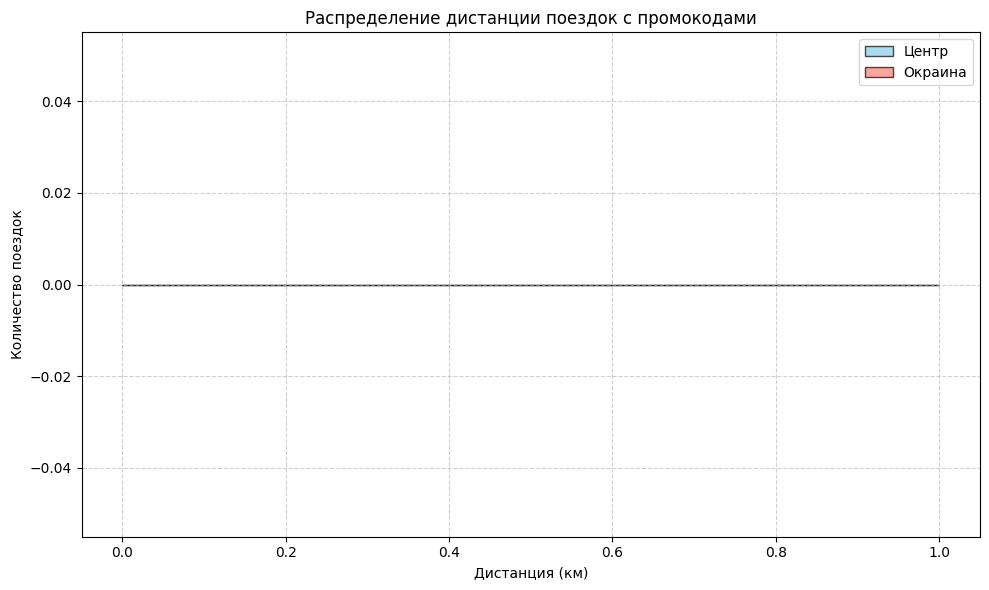

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Добавим сымитированные данные о дистанции
np.random.seed(42)
df['Distance'] = np.where(
    df['Start District'] == 'Center',
    np.random.normal(loc=5, scale=1, size=len(df)),  # Центр — короче
    np.random.normal(loc=12, scale=2, size=len(df))  # Окраина — длиннее
)

# Фильтрация поездок с промокодом
promo_trips = df[df['Promo_used']]

# Распределения по Центру и Окраине
center_distances = promo_trips[promo_trips['Start District'] == 'Center']['Distance']
suburb_distances = promo_trips[promo_trips['Start District'] == 'Suburb']['Distance']

# Построение графика
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(center_distances, bins=15, alpha=0.7, label='Центр', color='skyblue', edgecolor='black')
ax.hist(suburb_distances, bins=15, alpha=0.7, label='Окраина', color='salmon', edgecolor='black')
ax.set_title('Распределение дистанции поездок с промокодами')
ax.set_xlabel('Дистанция (км)')
ax.set_ylabel('Количество поездок')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [ ]:
df[df['Promo_used']].groupby('Start District')['Distance'].mean()
df[df['Promo_used']].groupby('Start District')['Promo'].count()

,Promo
Start District,
Заречный,162
Ленинский,244
Октябрьский,213
Северо-Западный,250
Центральный,248
Юго-Восточный,288
заречный,63
ленинский,117
октябрьский,71


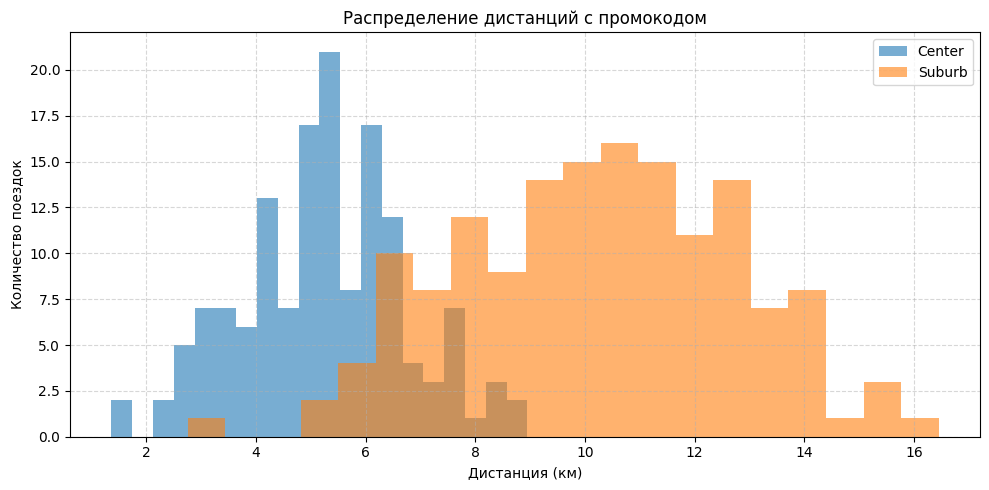

<Figure size 800x500 with 0 Axes>

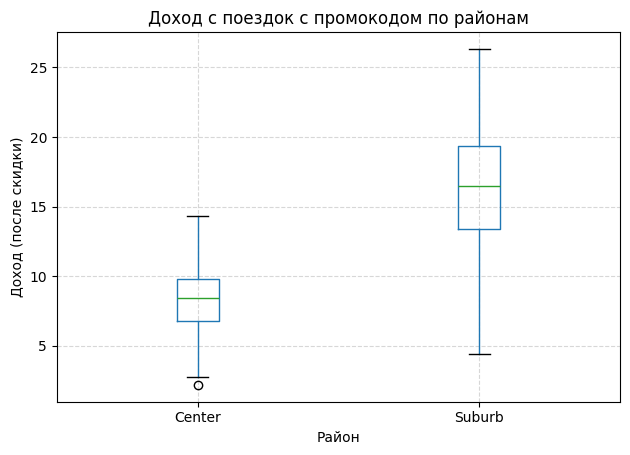

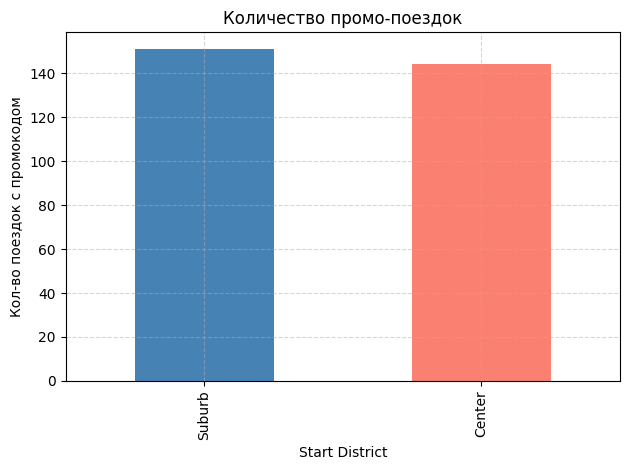

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Имитация данных
np.random.seed(42)
n = 500
df = pd.DataFrame({
    'Start District': np.random.choice(['Center', 'Suburb'], n),
    'Promo': np.random.choice([0, 1], n, p=[0.4, 0.6])
})
df['Promo_used'] = df['Promo'] == 1
df['Distance'] = np.where(
    df['Start District'] == 'Center',
    np.random.normal(loc=5, scale=1.5, size=n),
    np.random.normal(loc=10, scale=2.5, size=n)
)
df['Distance'] = df['Distance'].clip(lower=0.5)
df['Promo_income'] = df['Distance'] * 2 * (1 - 0.2)  # 20% скидка

# Фильтруем только поездки с промокодом
promo_df = df[df['Promo_used']]

# 🎯 1. Распределение дистанций
plt.figure(figsize=(10, 5))
for district in ['Center', 'Suburb']:
    subset = promo_df[promo_df['Start District'] == district]
    plt.hist(subset['Distance'], bins=20, alpha=0.6, label=district)
plt.title("Распределение дистанций с промокодом")
plt.xlabel("Дистанция (км)")
plt.ylabel("Количество поездок")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 🎯 2. Boxplot дохода с поездок по районам
plt.figure(figsize=(8, 5))
promo_df.boxplot(column='Promo_income', by='Start District')
plt.title("Доход с поездок с промокодом по районам")
plt.suptitle("")
plt.xlabel("Район")
plt.ylabel("Доход (после скидки)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 🎯 3. Кол-во поездок с промокодами по районам
promo_counts = promo_df['Start District'].value_counts()
promo_counts.plot(kind='bar', color=['steelblue', 'salmon'], title='Количество промо-поездок')
plt.ylabel('Кол-во поездок с промокодом')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


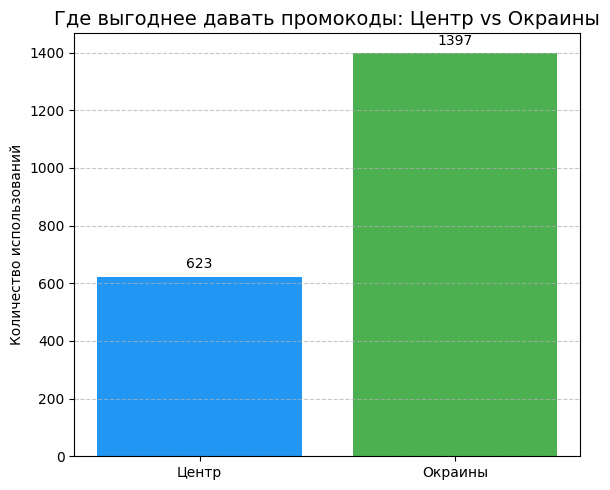

In [ ]:

import matplotlib.pyplot as plt

# Данные по районам
districts = {
    "Заречный": 113 + 44,
    "Ленинский": 230 + 73,
    "Октябрьский": 190 + 74,
    "Северо-Западный": 2 + 235 + 0 + 88,
    "Центральный": 482 + 141,
    "Юго-Восточный": 250 + 98,
}

# Разделение на центр и окраины
center = ["Центральный"]
suburbs = ["Заречный", "Ленинский", "Октябрьский", "Северо-Западный", "Юго-Восточный"]

# Суммируем значения
center_total = sum(districts[d] for d in center)
suburbs_total = sum(districts[d] for d in suburbs)

# Подготовка данных
categories = ["Центр", "Окраины"]
values = [center_total, suburbs_total]
colors = ["#2196F3", "#4CAF50"]

# Построение графика
plt.figure(figsize=(6, 5))
bars = plt.bar(categories, values, color=colors)
plt.title("Где выгоднее давать промокоды: Центр vs Окраины", fontsize=14)
plt.ylabel("Количество использований")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Подписи над столбцами
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 20, str(height), ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [ ]:
Когда лучше выдавать промокод:
Дата и время использования промокодов
День недели (будний/выходной)
Время суток (утро, день, вечер, ночь)
Сезонность (месяцы, праздники, акции)
Поведение клиентов (например, повторные покупки)


SyntaxError: invalid syntax (<ipython-input-3-7836f718e532>, line 1)

<ipython-input-8-acd3cfaacc7c>:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df["Promo"] == 1], x="Time of Day", order=["Утро", "День", "Вечер", "Ночь"], palette="Set2")


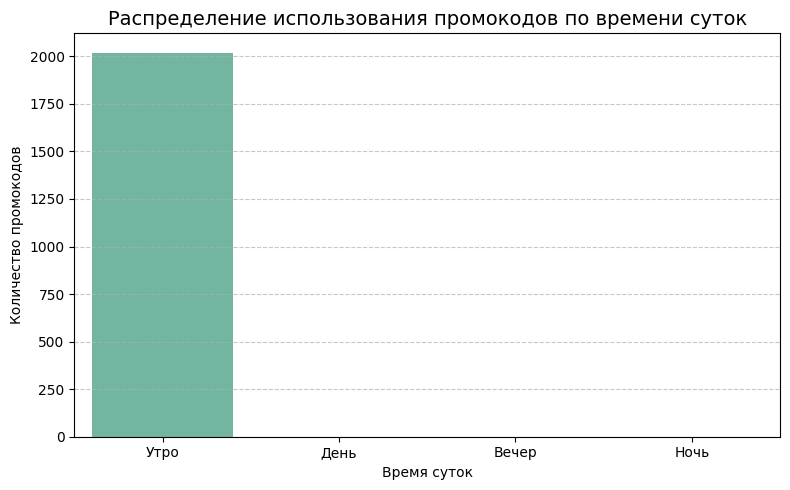

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("rides.csv")

# Преобразование даты
df["Start Date"] = pd.to_datetime(df["Start Date"])
df["Hour"] = df["Start Date"].dt.hour

# Классификация по времени суток
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return "Утро"
    elif 12 <= hour < 17:
        return "День"
    elif 17 <= hour < 21:
        return "Вечер"
    else:
        return "Ночь"

df["Time of Day"] = df["Hour"].apply(get_time_of_day)

# Построение графика
plt.figure(figsize=(8, 5))
sns.countplot(data=df[df["Promo"] == 1], x="Time of Day", order=["Утро", "День", "Вечер", "Ночь"], palette="Set2")
plt.title("Распределение использования промокодов по времени суток", fontsize=14)
plt.xlabel("Время суток")
plt.ylabel("Количество промокодов")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


<ipython-input-10-d7fa042829fa>:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=promo_df, x="Time of Day", order=["Утро", "День", "Вечер", "Ночь"], palette="Set2")


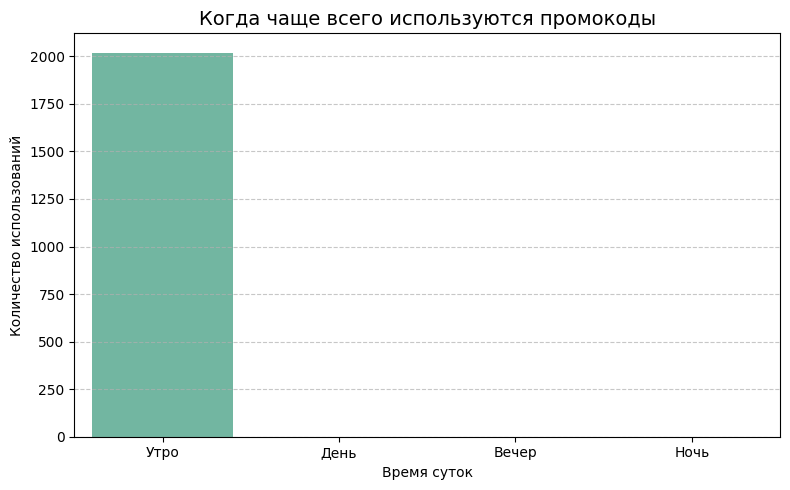

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv("rides.csv")

# Преобразуем дату
df["Start Date"] = pd.to_datetime(df["Start Date"])
df["Hour"] = df["Start Date"].dt.hour

# Классификация времени суток
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return "Утро"
    elif 12 <= hour < 17:
        return "День"
    elif 17 <= hour < 21:
        return "Вечер"
    else:
        return "Ночь"

df["Time of Day"] = df["Hour"].apply(get_time_of_day)

# Фильтруем по использованным промокодам
promo_df = df[df["Promo"] == 1]

# Построение графика
plt.figure(figsize=(8, 5))
sns.countplot(data=promo_df, x="Time of Day", order=["Утро", "День", "Вечер", "Ночь"], palette="Set2")
plt.title("Когда чаще всего используются промокоды", fontsize=14)
plt.xlabel("Время суток")
plt.ylabel("Количество использований")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


<ipython-input-11-9a9a604e4e71>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df["Promo"] == 1], x="Weekday",


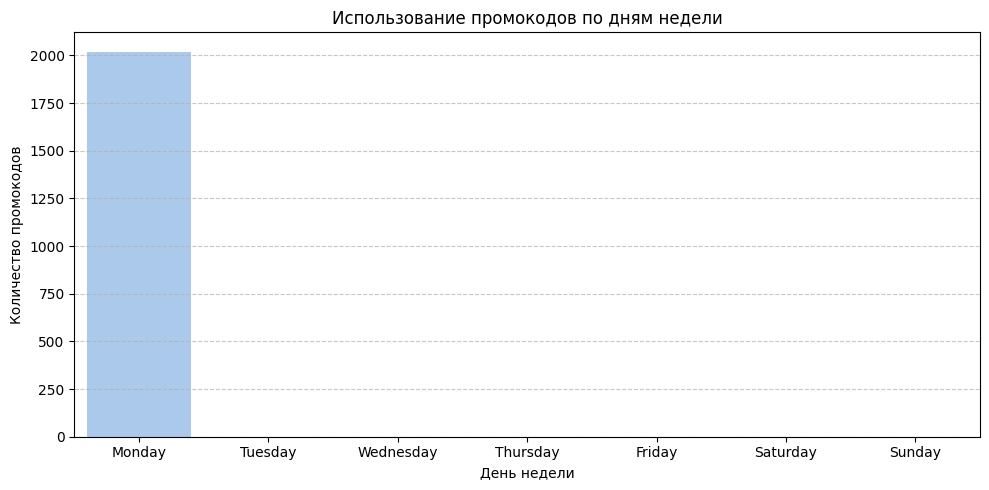

In [ ]:
# День недели
df["Weekday"] = df["Start Date"].dt.day_name()

# График
plt.figure(figsize=(10, 5))
sns.countplot(data=df[df["Promo"] == 1], x="Weekday",
              order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
              palette="pastel")
plt.title("Использование промокодов по дням недели")
plt.xlabel("День недели")
plt.ylabel("Количество промокодов")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


<ipython-input-12-19f22e7eda5d>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df["Promo"] == 1], x="Month",


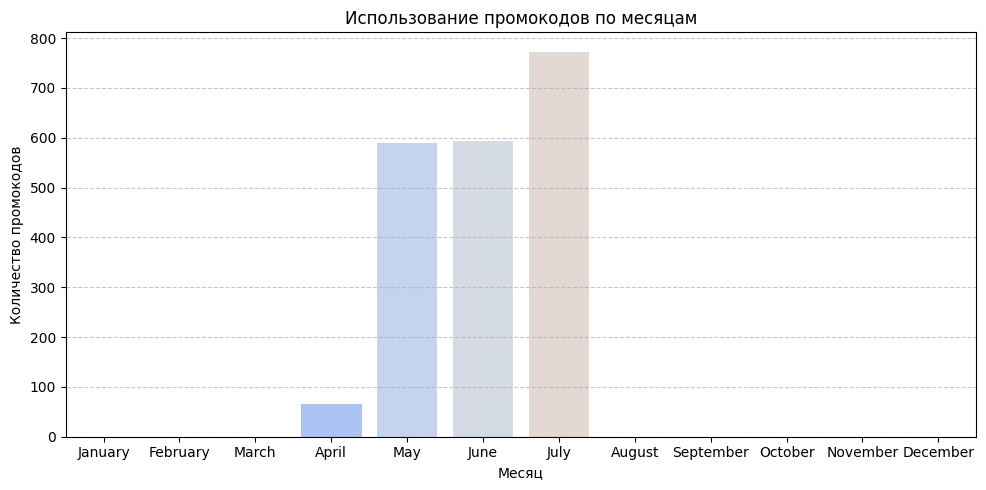

In [ ]:
# Название месяца
df["Month"] = df["Start Date"].dt.month_name()

# График
plt.figure(figsize=(10, 5))
sns.countplot(data=df[df["Promo"] == 1], x="Month",
              order=pd.date_range("2023-01-01", periods=12, freq="MS").strftime("%B"),
              palette="coolwarm")
plt.title("Использование промокодов по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Количество промокодов")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


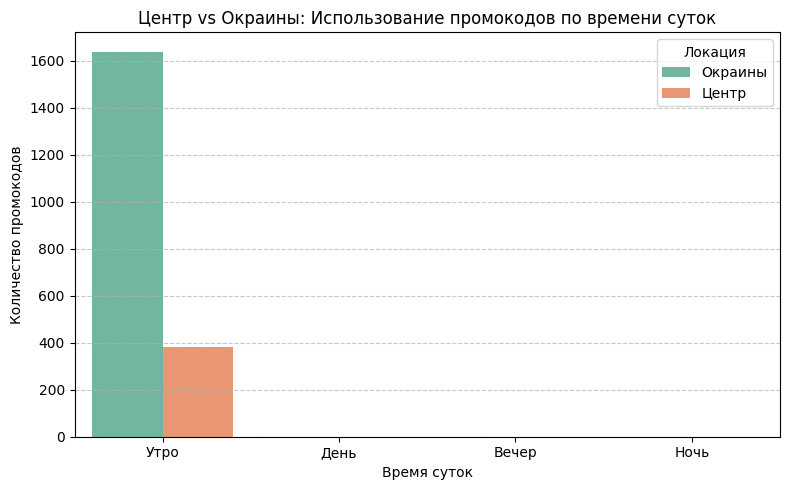

In [ ]:
# Приводим все районы к нижнему регистру
df["Start District"] = df["Start District"].str.lower()

# Списки районов
center_districts = ["центральный"]
suburb_districts = ["заречный", "ленинский", "октябрьский", "северо-западный", "юго-восточный"]

# Определяем зону: Центр или Окраины
def get_zone(district):
    if district in center_districts:
        return "Центр"
    elif district in suburb_districts:
        return "Окраины"
    else:
        return "Прочее"

df["Zone"] = df["Start District"].apply(get_zone)

# Фильтр по промокодам
promo_df = df[df["Promo"] == 1]

# График
plt.figure(figsize=(8, 5))
sns.countplot(data=promo_df, x="Time of Day", hue="Zone", order=["Утро", "День", "Вечер", "Ночь"], palette="Set2")
plt.title("Центр vs Окраины: Использование промокодов по времени суток")
plt.xlabel("Время суток")
plt.ylabel("Количество промокодов")
plt.legend(title="Локация")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Насколько чаще люди берут самокаты в какую либо погоду

Datetime               object
Temperature            object
Precipitation Total    object
Wind Gust              object
Wind Speed             object
Cloud Cover Total      object
Sunshine Duration      object
dtype: object
Datetime                object
Temperature            float64
Precipitation Total    float64
Wind Gust              float64
Wind Speed             float64
Cloud Cover Total      float64
Sunshine Duration      float64
dtype: object
Datetime                1
Temperature            56
Precipitation Total    31
Wind Gust               1
Wind Speed             17
Cloud Cover Total      21
Sunshine Duration      13
dtype: int64
              Datetime  Temperature  Precipitation Total  Wind Gust  \
0                  NaN    18.137779             0.101043  20.886568   
1  2023-04-01T00:00:00     8.740245             0.100000  48.600000   
2  2023-04-01T01:00:00     9.040245             0.200000  55.440000   
3  2023-04-01T02:00:00     8.880245             0.300000  55.80000

<ipython-input-17-c64681723401>:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df.groupby('Temperature Category').size()


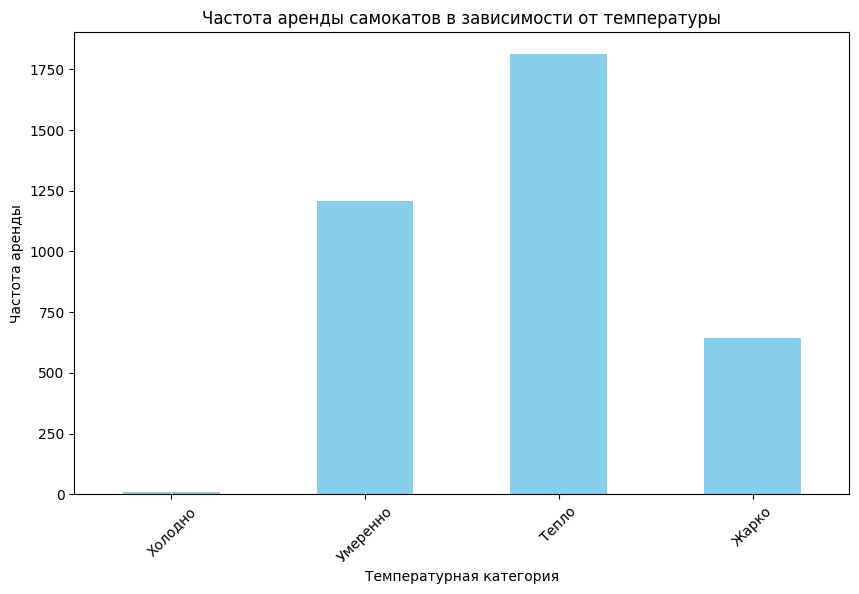

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Загрузка данных
df = pd.read_csv("weather.csv")

# Проверим типы данных и выявим, где присутствуют строки
print(df.dtypes)

# Преобразуем столбцы с погодными условиями в числовой формат и проверим наличие ошибок
columns_to_convert = ['Temperature', 'Precipitation Total', 'Wind Gust', 'Wind Speed', 'Cloud Cover Total', 'Sunshine Duration']

# Преобразуем столбцы в числовой тип, с заменой ошибок на NaN
for column in columns_to_convert:
    df[column] = pd.to_numeric(df[column], errors='coerce')  # Заменяем ошибки на NaN

# Проверим снова типы данных
print(df.dtypes)

# Проверяем на наличие NaN значений
print(df.isnull().sum())

# Заменим пропущенные значения на среднее по каждому столбцу только для числовых данных
df[columns_to_convert] = df[columns_to_convert].fillna(df[columns_to_convert].mean())

# Проверим несколько строк, чтобы убедиться, что данные теперь корректные
print(df.head())

# Разделим данные по погодным условиям (например, на основе осадков)
df['Rainy'] = df['Precipitation Total'] > 0

# Разделим на категории температуры (например, холодно, тепло, жарко)
bins = [-np.inf, 0, 15, 25, np.inf]  # Категории температуры
labels = ['Холодно', 'Умеренно', 'Тепло', 'Жарко']
df['Temperature Category'] = pd.cut(df['Temperature'], bins=bins, labels=labels)

# Группировка по категориям температуры
df_grouped = df.groupby('Temperature Category').size()

# Строим график
plt.figure(figsize=(10, 6))
df_grouped.plot(kind='bar', color='skyblue')
plt.title('Частота аренды самокатов в зависимости от температуры')
plt.xlabel('Температурная категория')
plt.ylabel('Частота аренды')
plt.xticks(rotation=45)
plt.show()


In [ ]:
Зависимость улиц друг от друга

       Id           Start Date             End Date Start Location  \
0  100340  2023-04-22 09:01:03  2023-04-22 09:24:45       Шевченко   
1  100341  2023-04-22 09:01:07  2023-04-22 09:29:32         Чехова   
2  100342  2023-04-22 09:04:27  2023-04-22 09:42:46      Буденного   
3  100343  2023-04-22 09:06:34  2023-04-22 09:38:23          Труда   
4  100344  2023-04-22 09:09:27  2023-04-22 09:40:07   Первомайская   

    Start District End Location     End District  Distance  Promo  
0    Юго-Восточный      Майская      Октябрьский    4069.0      0  
1         заречный   Спортивная      октябрьский    4515.0      0  
2      Октябрьский     Суворова        ленинский    4520.0      0  
3      Центральный      Рабочая  Северо-Западный    3881.0      0  
4  Северо-Западный    Юбилейная    Юго-Восточный    4029.0      0  
   Start Street  End Street
0      Шевченко     Майская
1        Чехова  Спортивная
2     Буденного    Суворова
3         Труда     Рабочая
4  Первомайская   Юбилейная
   

ValueError: Unknown format code 'd' for object of type 'float'

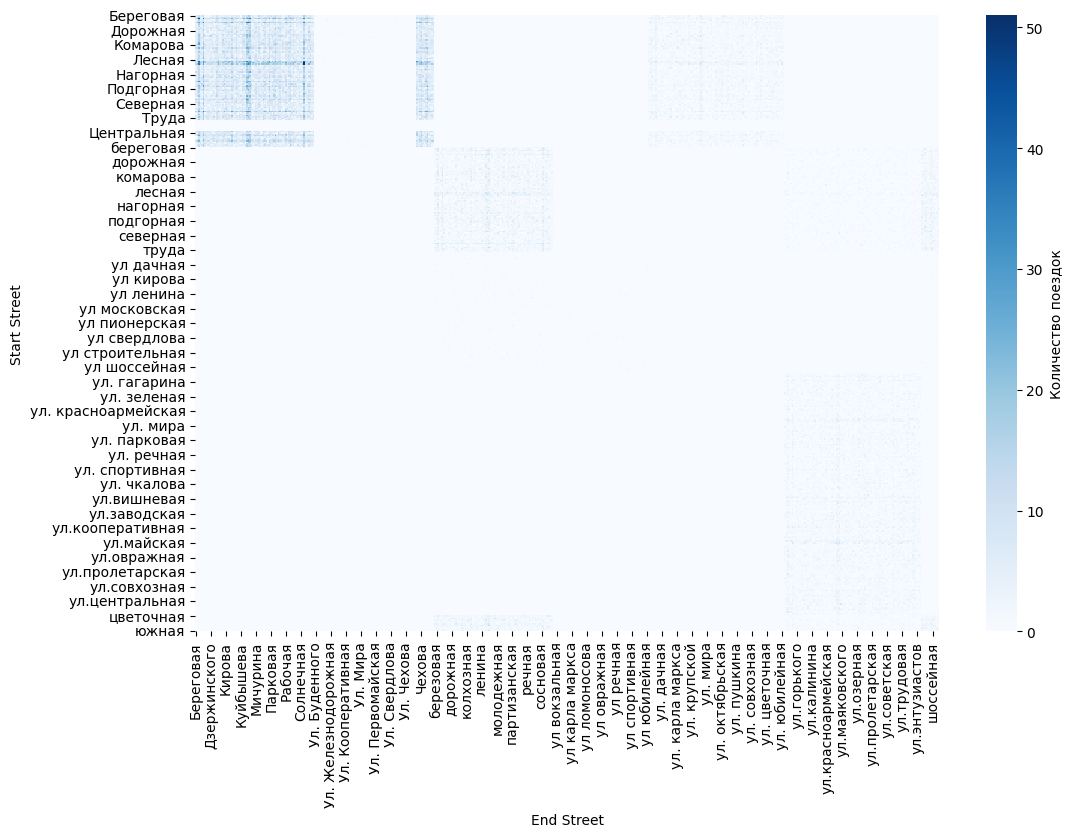

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
rides = pd.read_csv("rides.csv")  # Замените на актуальный путь к файлу

# Проверим структуру данных
print(rides.head())

# Выделим начальные и конечные улицы
start_streets = rides['Start Location']
end_streets = rides['End Location']

# Создадим таблицу частоты встречаемости пар "Start Location" - "End Location"
street_pairs = pd.concat([start_streets, end_streets], axis=1)
street_pairs.columns = ['Start Street', 'End Street']

# Посмотрим на первые несколько строк
print(street_pairs.head())

# Подсчитаем, сколько раз каждая пара улиц встречается
street_pair_counts = street_pairs.groupby(['Start Street', 'End Street']).size().reset_index(name='Count')

# Отсортируем по количеству встречаемых пар
street_pair_counts = street_pair_counts.sort_values(by='Count', ascending=False)

# Выведем топ-10 самых популярных пар улиц
print(street_pair_counts.head(10))

# Построим график зависимости между улицами

# Выберем топ-10 пар улиц для визуализации
top_street_pairs = street_pair_counts.head(10)

# Построим тепловую карту зависимости улиц
pivot_table = street_pair_counts.pivot_table(index='Start Street', columns='End Street', values='Count', fill_value=0)

# Визуализируем тепловую карту
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Количество поездок'})
plt.title('Зависимость между улицами (количество поездок)')
plt.xlabel('Конечная улица')
plt.ylabel('Начальная улица')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()
